# Photometry

> Author: *Valentin Christiaens*  
> Package dependencies: astropy, matplotlib, numpy, photutils, scikit-image, scipy
>
> Install with `pip install -r requirements.txt`
> 
> Last update: *2024/04/10*

---

## Table of contents

* [1. Aperture photometry of point sources](#1.-Aperture-photometry-of-point-sources)
    - [1.1. General procedure](#1.1.-General-procedure)
    - [1.2. Apertures](#1.2.-Apertures)
    - [1.3. Error estimation](#1.3.-Error-estimation)
    - [1.4. Aperture photometry with sky coordinates](#1.4.-Aperture-photometry-with-sky-coordinates)
* [2. Background subtraction](#2.-Background-subtraction)
    - [2.1. Constant value](#2.1.-Constant-value)
    - [2.2. Annular estimate](#2.2.-Annular-estimation)
    - [2.3. Gradient estimate](#2.3.-Gradient-estimate)
* [3. Source identification](#3.-Source-identification)
    - [3.1. Centroid measurement](#3.1.-Centroid-measurement)
    - [3.2. Image alignment](#3.2.-Image-alignment)
    - [3.3. Automatic source finding](#3.3.-Automatic-source-finding)

---

In this lecture, we will see how to tackle the common task of measuring the photometry (i.e. quantify the brightness) of point sources in astronomical images.

Before the advent of gravitational wave astronomy, *all* we knew about our Universe came from measuring the light of celestial objects. Chronologically: measurements were first made by eye (through an eyepiece after the invention of the telescope), then through photographic plates placed in the focal plane of the telescope, and more recently through electronic detectors (charge-coupled devices; CCD). 

Different instruments can be placed in the focal plane of a telescope to count photons, i.e. to perform **photometry**. Imagers (i.e. camera/detectors) provide the image of a field in which a number of sources may be located, and with source contributing the photon counts of different **pixels** in the image. 
Spectrographs are instruments dispersing the light coming from a given field-of-view before it hits the detector, and can come with various designs.
Some spectrograph designs enable the simultaneous acquisition of multi-wavelength images (e.g. integral field spectrographs), where the task of measuring photons from given sources is then referred to as **spectro-photometry**.

Note that high-spectral resolution spectrographs (e.g. Echelle spectrographs) typically do not provide spatial information - all the incoming light is dispersed. The outcome then takes the form of a 1D spectrum for the observed object/field.

**Goals of this lecture:** 

1. Be able to measure the photometry of point sources.
2. Be able to estimate and subtract the background contribution.
3. Know how to identify sources and measure their centroid location.
4. Know how to register observed images before stacking them.

In [1]:
# Let's import modules we will use a lot in this tutorial:
from matplotlib import pyplot as plt
import numpy as np

## 1. Aperture photometry of point sources

The most direct way to quantify the brightness of sources in astronomical images is to perform **aperture photometry**, that is to count and sum the number of photon hits on pixels within a given aperture encompassing the source.

The size of the aperture should be well chosen to either capture most of the flux of the star, or a well-characterized fraction of the whole incoming flux.

The package offering the most options in that purpose is the Astropy-affiliated package `photutils`.

The `aperture_photometry()` function and the `ApertureStats` class are the main tools to perform aperture photometry on an astronomical image for a given set of apertures.

Photutils provides several apertures defined in pixel or sky coordinates. The aperture classes that are defined in pixel coordinates are:

- `CircularAperture`
- `CircularAnnulus`
- `EllipticalAperture`
- `EllipticalAnnulus`
- `RectangularAperture`
- `RectangularAnnulus`

Each of these classes has a corresponding variant defined in sky coordinates:

- `SkyCircularAperture`
- `SkyCircularAnnulus`
- `SkyEllipticalAperture`
- `SkyEllipticalAnnulus`
- `SkyRectangularAperture`
- `SkyRectangularAnnulus`

To perform aperture photometry with sky-based apertures, one needs to specify a WCS transformation.

### 1.1. General procedure

The first step in performing aperture photometry with `photutils` is to create an **aperture object**. An aperture object is defined by a position (or a list of positions) and parameters that define its size and possibly, orientation (e.g., for an elliptical aperture).

**Example**: Let's create a circular aperture in pixel coordinates using the `CircularAperture` class:

In [2]:
from photutils.aperture import CircularAperture

aperture = CircularAperture((30, 30), r=3.0)

After the aperture object is created, we can perform the photometry using the `aperture_photometry()` function, providing it both the data and the aperture(s).

**Example:** Let's consider an array of all ones and integrate the flux over the apertures defined above. 

In [3]:
from photutils.aperture import aperture_photometry

data = np.ones((100, 100))
phot_table = aperture_photometry(data, aperture)

In [4]:
#phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
print(phot_table)

 id xcenter ycenter    aperture_sum   
      pix     pix                     
--- ------- ------- ------------------
  1    30.0    30.0 28.274333882308134


This function returns the results of the photometry in an Astropy **QTable**. In this example, the table has four columns, named 'id', 'xcenter', 'ycenter', and 'aperture_sum'.

Since all the data values are 1.0, the aperture sums are equal to the area of a circle with a radius of 3:

In [5]:
print(np.pi * 3.0** 2)

28.274333882308138


### 1.2. Apertures

Photutils provides several apertures defined in pixel or sky coordinates. The aperture classes that are defined in pixel coordinates are:

- `CircularAperture`
- `CircularAnnulus`
- `EllipticalAperture`
- `EllipticalAnnulus`
- `RectangularAperture`
- `RectangularAnnulus`

Let's assume we want to consider several apertures at once:

In [6]:
from photutils.aperture import CircularAperture

positions = [(30.0, 30.0), (40.0, 40.0)]
apertures = CircularAperture(positions, r=3.0)

The positions should be either a single tuple of (x, y) - as seen in the previous section - or a list of (x, y) tuples, or an array with shape Nx2, where N is the number of positions.

The above example defines two circular apertures with a radius of 3 pixels, and located at pixel coordinates (30, 30) and (40, 40).

In [7]:
phot_table = aperture_photometry(data, apertures)
print(phot_table)

 id xcenter ycenter    aperture_sum   
      pix     pix                     
--- ------- ------- ------------------
  1    30.0    30.0 28.274333882308134
  2    40.0    40.0 28.274333882308134


One can also consider a list of apertures, for example with **multiple aperture sizes**:

In [8]:
radii = [3.0, 4.0, 5.0]
apertures = [CircularAperture(positions, r=r) for r in radii]

In [9]:
phot_table = aperture_photometry(data, apertures)
print(phot_table)

 id xcenter ycenter   aperture_sum_0     aperture_sum_1    aperture_sum_2 
      pix     pix                                                         
--- ------- ------- ------------------ ----------------- -----------------
  1    30.0    30.0 28.274333882308134 50.26548245743669 78.53981633974485
  2    40.0    40.0 28.274333882308134 50.26548245743669 78.53981633974485


<a class="anchor" id="det1"></a> <div class="alert alert-block alert-warning"> 
**Exercise 1.1:** Measure the aperture photometry of star HD 135344 B ('data/SPHERE_PSF_HD135.fits') in detector units for different, increasing, aperture sizes (from 1 to 80 pixels by steps of 1). Make a plot of the measured flux as a function of aperture size, and estimate the aperture radius which encompasses half of the total energy.

Tip: here it is fine to consider the coordinates of the peak intensity pixel for the center of the aperture.
</div>

In [10]:
from astropy.io import fits
image = fits.getdata('data/SPHERE_PSF_HD135.fits')

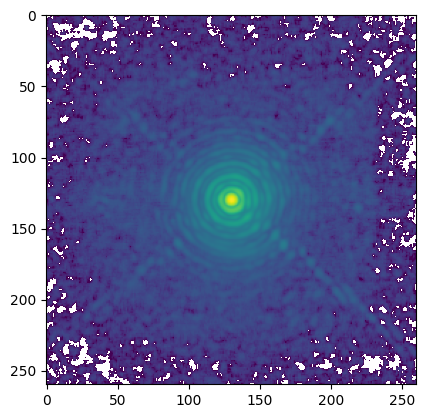

In [11]:
from matplotlib.colors import LogNorm

plt.imshow(image, norm=LogNorm(vmin=1, vmax=np.amax(image)))

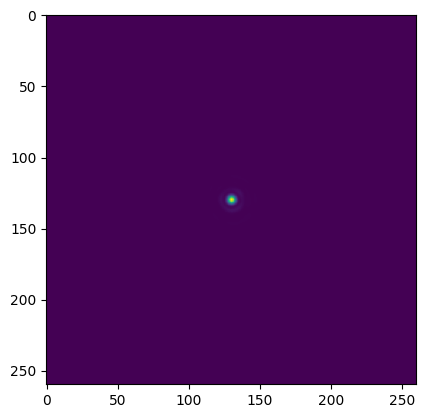

In [12]:
from matplotlib.colors import LogNorm

plt.imshow(image)

In [13]:
max_yx = np.argmax(image)
print(max_yx)

33930


In [14]:
cy, cx = np.unravel_index(max_yx, image.shape)
cy, cx

(130, 130)

In [15]:
radii = range(1, 81)
position = (cx, cy)
apertures = [CircularAperture(position, r=r) for r in radii]

In [16]:
phot_table = aperture_photometry(image, apertures)
phot_table

id,xcenter,ycenter,aperture_sum_0,aperture_sum_1,aperture_sum_2,aperture_sum_3,aperture_sum_4,aperture_sum_5,aperture_sum_6,aperture_sum_7,aperture_sum_8,aperture_sum_9,aperture_sum_10,aperture_sum_11,aperture_sum_12,aperture_sum_13,aperture_sum_14,aperture_sum_15,aperture_sum_16,aperture_sum_17,aperture_sum_18,aperture_sum_19,aperture_sum_20,aperture_sum_21,aperture_sum_22,aperture_sum_23,aperture_sum_24,aperture_sum_25,aperture_sum_26,aperture_sum_27,aperture_sum_28,aperture_sum_29,aperture_sum_30,aperture_sum_31,aperture_sum_32,aperture_sum_33,aperture_sum_34,aperture_sum_35,aperture_sum_36,aperture_sum_37,aperture_sum_38,aperture_sum_39,aperture_sum_40,aperture_sum_41,aperture_sum_42,aperture_sum_43,aperture_sum_44,aperture_sum_45,aperture_sum_46,aperture_sum_47,aperture_sum_48,aperture_sum_49,aperture_sum_50,aperture_sum_51,aperture_sum_52,aperture_sum_53,aperture_sum_54,aperture_sum_55,aperture_sum_56,aperture_sum_57,aperture_sum_58,aperture_sum_59,aperture_sum_60,aperture_sum_61,aperture_sum_62,aperture_sum_63,aperture_sum_64,aperture_sum_65,aperture_sum_66,aperture_sum_67,aperture_sum_68,aperture_sum_69,aperture_sum_70,aperture_sum_71,aperture_sum_72,aperture_sum_73,aperture_sum_74,aperture_sum_75,aperture_sum_76,aperture_sum_77,aperture_sum_78,aperture_sum_79
,pix,pix,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,130.0,130.0,585121.7691673004,2005707.4516493483,3459989.3419748833,4365163.511515119,4706525.410595547,4836173.274303704,5034672.038044423,5306442.156638848,5520756.702172188,5622402.594953012,5665776.138694735,5710733.553184696,5759840.11961692,5795942.9960948555,5830327.3568230495,5888155.016249168,5967374.160372417,6038600.645692236,6082140.655451969,6106235.0218338035,6127273.160526696,6148915.6614392735,6167477.732273772,6186534.372070054,6214341.922152576,6250347.605090895,6283642.093346218,6306610.903852515,6322882.310648238,6339463.914155671,6357329.167062833,6373231.085402324,6387053.864385625,6402226.985417733,6419713.958641389,6436192.451685134,6449328.996094731,6461399.703401911,6475501.368502225,6490924.567218058,6504460.373038027,6514882.917965936,6523820.831666409,6532787.042974213,6541340.616127798,6549202.364922022,6557853.007543378,6568593.699138259,6580362.087250757,6590718.345006056,6598666.2465138575,6605329.993664,6612016.167746656,6618690.059844481,6625219.397221123,6632046.376730595,6639756.908957094,6647890.722341331,6655355.880261019,6661862.34364904,6668059.660577722,6674369.744198676,6680649.3656932805,6686681.330711024,6692709.337566923,6699155.104458456,6705865.025887571,6712417.57197635,6718775.1623902675,6725367.945819703,6732368.256434996,6739457.263267811,6746213.990336685,6752554.444810079,6758687.821861204,6764820.735776514,6771079.287837877,6777627.445087061,6784608.709403216,6791952.081355901


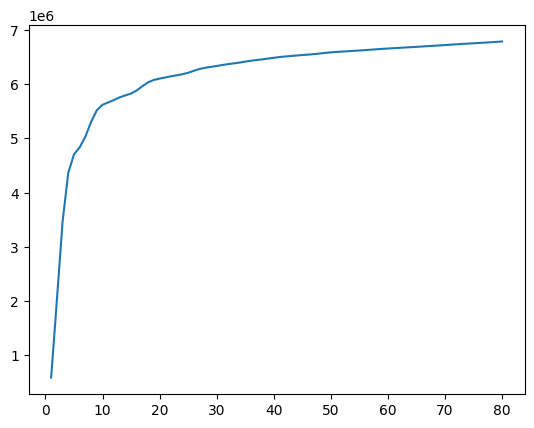

In [17]:
fluxes = [float(phot_table['aperture_sum_{}'.format(r-1)][0]) for r in radii]
plt.plot(radii, fluxes)

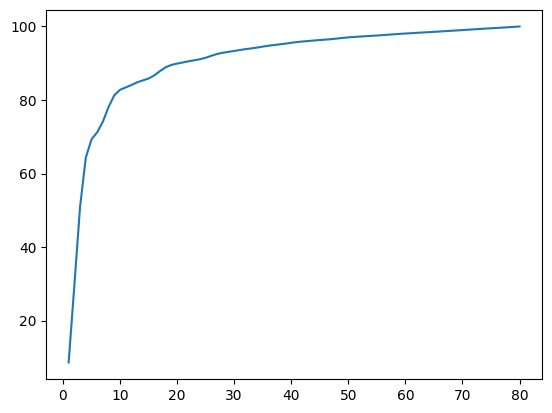

In [18]:
enc_energy = [fluxes[i]/fluxes[-1] for i in range(len(fluxes))]
enc_energy = 100*np.array(enc_energy)
plt.plot(radii, enc_energy)

Find the closest aperture to 50%:

In [19]:
radii[np.argmin(np.abs(enc_energy-50))]

3

**Alternative** (shortcut) method using `CurveOfGrowth` to plot the profile:

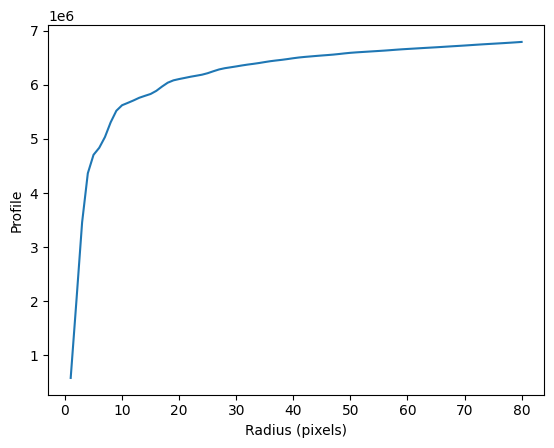

In [20]:
from photutils.profiles import CurveOfGrowth
radii = np.arange(1, 81)
cog = CurveOfGrowth(image, position, radii)

cog.plot()

### 1.3. Error estimation

If and only if the `error` keyword is input to `aperture_photometry()`, the returned table will include a 'aperture_sum_err' column in addition to 'aperture_sum'. 'aperture_sum_err' provides the propagated uncertainty associated with 'aperture_sum'.

**Example:**

In [21]:
positions = [(30.0, 30.0), (40.0, 40.0)]
aperture = CircularAperture(positions, r=3.0)
data = np.ones((100, 100))
error = 0.1 * data

phot_table = aperture_photometry(data, aperture, error=error)
for col in phot_table.colnames:
    phot_table[col].info.format = '%.8g'  # for consistent table output: force 8 significant digits
print(phot_table)

 id xcenter ycenter aperture_sum aperture_sum_err
      pix     pix                                
--- ------- ------- ------------ ----------------
  1      30      30    28.274334       0.53173616
  2      40      40    28.274334       0.53173616


### 1.4. Aperture photometry with sky coordinates

Analogous to detector-based apertures, one can also define apertures in sky coordinates:

- `SkyCircularAperture`
- `SkyCircularAnnulus`
- `SkyEllipticalAperture`
- `SkyEllipticalAnnulus`
- `SkyRectangularAperture`
- `SkyRectangularAnnulus`


Creating an aperture object in sky coordinates is straightforward. One first uses the `SkyCoord` class to define sky coordinates and then the `SkyCircularAperture` class to define the aperture object:

In [22]:
from astropy import units as u
from astropy.coordinates import SkyCoord
from photutils.aperture import SkyCircularAperture

positions_sky = SkyCoord(l=[1.2, 2.3] * u.deg, b=[0.1, 0.2] * u.deg, frame='galactic')
aperture_sky = SkyCircularAperture(positions_sky, r=4.0 * u.arcsec)

Then to perform aperture photometry with sky-based apertures, one needs to specify a WCS transformation.

**Example:** Let's measure the photometry of sources in a Spitzer 4.5 micron image of a region of the Galactic plane.

In [23]:
import astropy.units as u
from astropy.wcs import WCS
from photutils.datasets import load_spitzer_catalog, load_spitzer_image

spitzer_hdu = load_spitzer_image()
spitzer_image = spitzer_hdu.data
data = u.Quantity(spitzer_image, unit=spitzer_hdu.header['BUNIT'])  
wcs = WCS(spitzer_hdu.header)  
catalog = load_spitzer_catalog()  

In [24]:
spitzer_hdu.header['BUNIT']

'MJy/sr'

Let's visualize the Spitzer image:

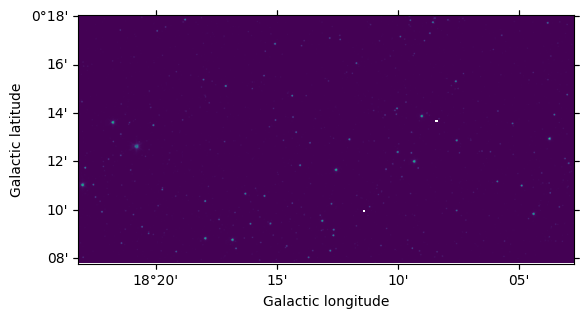

In [25]:
ax = plt.subplot(projection=wcs)   # This initialises your axes transforming it to WCS 
ax.imshow(spitzer_image, origin='lower')
#ax.grid(color='white', ls='solid')
ax.set_xlabel('Galactic longitude')
ax.set_ylabel('Galactic latitude')

The catalog contains (among other things) the Galactic coordinates of the sources in the image as well as the PSF-fitted fluxes from the official Spitzer data reduction. We define the apertures positions based on the existing catalog positions:

In [26]:
from astropy.coordinates import SkyCoord

positions = SkyCoord(catalog['l'], catalog['b'], frame='galactic')  
aperture = SkyCircularAperture(positions, r=4.8 * u.arcsec) 

Now perform the photometry in these apertures on the data. The wcs object contains the WCS transformation of the image obtained from the FITS header. It includes the coordinate frame of the image and the projection from sky to pixel coordinates. The aperture_photometry function uses the WCS information to automatically convert the apertures defined in sky coordinates into pixel coordinates:

In [27]:
phot_table = aperture_photometry(data, aperture, wcs=wcs)  

In [28]:
import astropy.units as u
factor = (1.2 * u.arcsec) ** 2 / u.pixel
fluxes_catalog = catalog['f4_5']  
converted_aperture_sum = (phot_table['aperture_sum'] *
                          factor).to(u.mJy / u.pixel)  

Finally, we can plot the comparison of the photometry:

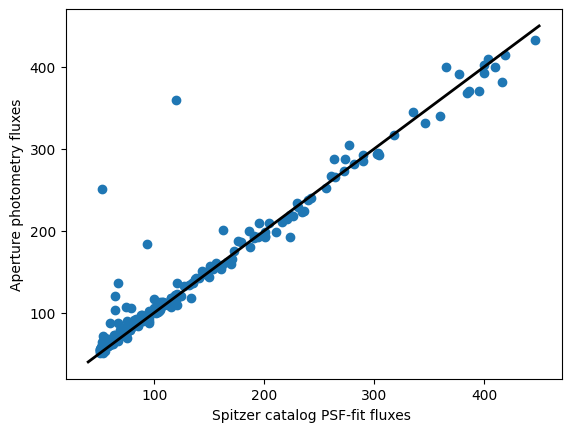

In [29]:
import matplotlib.pyplot as plt
plt.scatter(fluxes_catalog, converted_aperture_sum.value)
plt.xlabel('Spitzer catalog PSF-fit fluxes ')
plt.ylabel('Aperture photometry fluxes')
plt.plot([40, 100, 450], [40, 100, 450], color='black', lw=2)

<a class="anchor" id="det1"></a> <div class="alert alert-block alert-warning"> 
**Exercise 2.1:** Read in the file `data/HelixNebula.fits` and:

1. Define a SkyCoord object containing the sky coordinates of the Helix nebula.
2. Measure the integrated flux at these sky coordinates in the image. Consider an aperture of 15 arcmin radius.

</div>

In [30]:
c_helix = SkyCoord.from_name("Helix nebula")
c_helix

<SkyCoord (ICRS): (ra, dec) in deg
    (337.41060585, -20.83715201)>

In [31]:
img_helix, head_helix = fits.getdata('data/HelixNebula.fits', header=True)

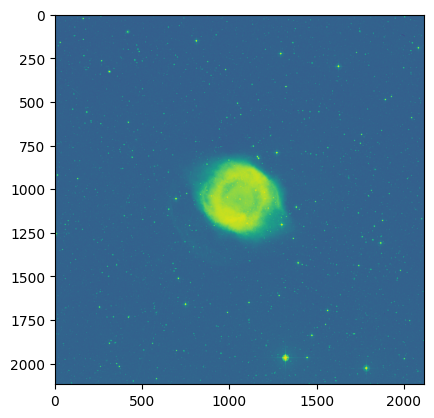

In [32]:
plt.imshow(img_helix)

In [33]:
w_hel = WCS(head_helix)

In [34]:
aperture = SkyCircularAperture(c_helix, r=15 * u.arcmin)

In [35]:
phot_table = aperture_photometry(img_helix, aperture, wcs=w_hel)
phot_table

id,xcenter,ycenter,sky_center,aperture_sum
,pix,pix,"deg,deg",
int64,float64,float64,SkyCoord,float64
1,1058.6419991426858,1059.036855108618,"337.41060585,-20.83715201",8235314662.763344


## 2. Background subtraction

By default `aperture_photometry()` assumes that the input data have been background-subtracted. 

### 2.1. Constant value

If `bkg` is a float value or an array representing the background of the data (e.g., determined by Background2D or an external function), one can simply subtract the background from the data before aperture photometry:

In [36]:
data = np.ones((100, 100))
bkg = 0.1
aperture = CircularAperture((30, 30), r=3.0)
phot_table = aperture_photometry(data - bkg, aperture) 
print(phot_table)

 id xcenter ycenter    aperture_sum   
      pix     pix                     
--- ------- ------- ------------------
  1    30.0    30.0 25.446900494077326


A very convenient function to estimate the mean background level is `sigma_clipped_stats`. It will calculate image statistics on pixels whose intensity is below a certain threshold set by median+sigma*standard_deviation, where sigma is set by the user.

**Example:** Let's estimate the background in the Spitzer image

In [37]:
from astropy.stats import sigma_clipped_stats
mean_bkg, median_bkg, std_bkg = sigma_clipped_stats(spitzer_image, sigma=3.0)
print((mean_bkg , median_bkg , std_bkg)) 

(4.286413, 3.836381, 1.6192979)


Given the potential presence of outliers, it is better to take the median.

One can notice that lowering the sigma threshold also lowers the mean/median background level:

In [38]:
from astropy.stats import sigma_clipped_stats
mean_bkg , median_bkg, std_bkg  = sigma_clipped_stats(spitzer_image, sigma=2.5)
print((mean_bkg , median_bkg , std_bkg)) 

(4.042252, 3.7515738, 1.2752802)


<a class="anchor" id="det1"></a> <div class="alert alert-block alert-warning"> 
**Exercise 2.2:** Read in the file `data/M13_blue_0001.fits` and:

1. Estimate uncertainties on the pixel intensities. Assume that the latter correspond to photon counts, and consider Poisson noise uncertainties.
2. Estimate and subtract the background from the image.
3. Measure the flux for the brightest point source in the M13 field in a 4 pixel-radius aperture, including error.

</div>

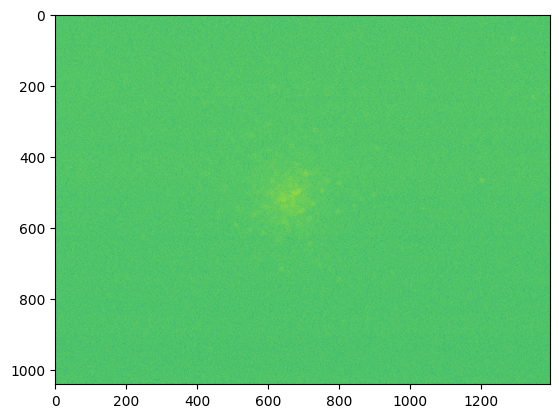

In [39]:
img_M13 = fits.getdata('data/M13_blue_0001.fits')
plt.imshow(img_M13)

In [40]:
_, median_bkg, _ = sigma_clipped_stats(img_M13, sigma=2.5)
median_bkg

513.0

In [41]:
img_M13_bgsub = img_M13 - median_bkg

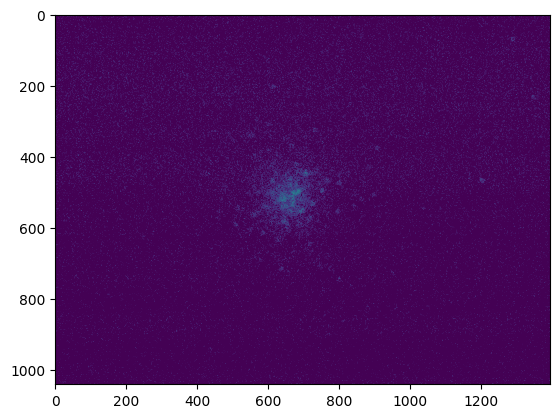

In [42]:
plt.imshow(img_M13_bgsub, vmin=0)

In [43]:
unc_M13 = np.sqrt(img_M13)

In [44]:
max_coords = np.argmax(img_M13_bgsub)
cy, cx = np.unravel_index(max_coords, img_M13_bgsub.shape)
cy, cx

(528, 648)

In [45]:
aperture = CircularAperture((cx, cy), r=4)

In [46]:
phot_table = aperture_photometry(img_M13_bgsub, aperture, error=unc_M13)
phot_table

id,xcenter,ycenter,aperture_sum,aperture_sum_err
,pix,pix,,
int64,float64,float64,float64,float64
1,648.0,528.0,1977.652880173452,166.6248631281988


### 2.2. Annular estimate

One often wants to also estimate the **local background** around each source using a nearby aperture or annulus aperture surrounding each source. A simple method for doing this is to use the `ApertureStats` class to compute the mean background level within the background aperture. This class can also be used to calculate more advanced statistics (e.g., a sigma-clipped median) within the background aperture (e.g., a circular annulus).

**Examples:** Let's first generate a more realistic dataset.

In [47]:
from photutils.datasets import make_100gaussians_image
data = make_100gaussians_image()

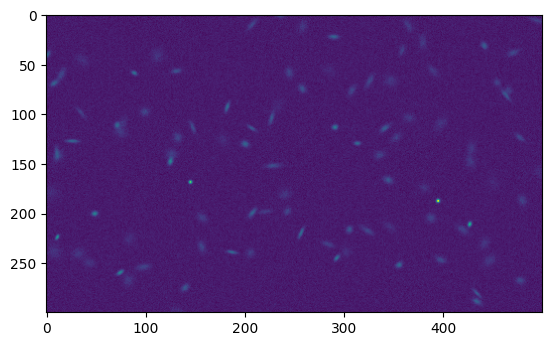

In [48]:
plt.imshow(data)

This artificial image has a known average background level of 5. Let's see if local background estimation manages to get rid of that contribution.

For this example we perform the photometry for three sources in a circular aperture with a radius of 5 pixels. The local background level around each source is estimated using a circular annulus of inner radius 10 pixels and outer radius 15 pixels. Let’s define the apertures:

In [49]:
from photutils.aperture import CircularAnnulus, CircularAperture

positions = [(145.1, 168.3), (84.5, 224.1), (48.3, 200.3)]
aperture = CircularAperture(positions, r=5)
annulus_aperture = CircularAnnulus(positions, r_in=10, r_out=15)

Now let’s plot the circular apertures (white) and circular annulus apertures (red) on a cutout from the image containing the three sources:

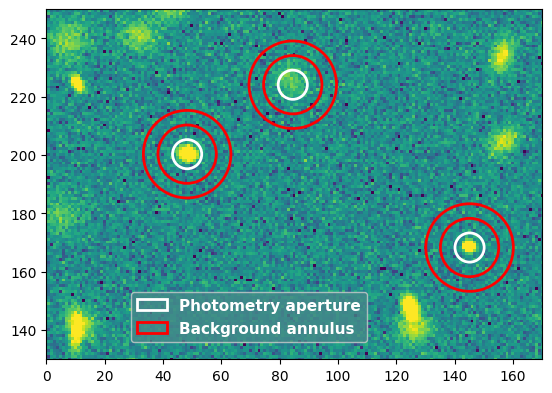

In [50]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from photutils.aperture import CircularAnnulus, CircularAperture
from photutils.datasets import make_100gaussians_image

norm = simple_norm(data, 'sqrt', percent=99)
plt.imshow(data, norm=norm, interpolation='nearest')
plt.xlim(0, 170)
plt.ylim(130, 250)

ap_patches = aperture.plot(color='white', lw=2,
                           label='Photometry aperture')
ann_patches = annulus_aperture.plot(color='red', lw=2,
                                    label='Background annulus')
handles = (ap_patches[0], ann_patches[0])
plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
           handles=handles, prop={'weight': 'bold', 'size': 11})


We can use the `ApertureStats` class to compute the mean background level within the annulus aperture at each position:

In [51]:
from photutils.aperture import ApertureStats
aperstats = ApertureStats(data, annulus_aperture)
bkg_mean = aperstats.mean
print(bkg_mean)  

[4.96369499 5.10467691 4.9497741 ]


Close enough. Then it is only a matter of scaling these values by the size of the aperture used for aperture photometry, and subtracting the total expected contribution from the background.

In [52]:
phot_table = aperture_photometry(data, aperture)
print(aperture.area)
total_bkg = bkg_mean * aperture.area
phot_bkgsub = phot_table['aperture_sum'] - total_bkg

78.53981633974483


Let's finally add the background estimates and background subtracted photometry to the table:

In [53]:
phot_table['total_bkg'] = total_bkg
phot_table['aperture_sum_bkgsub'] = phot_bkgsub
print(phot_table)

 id xcenter ycenter    aperture_sum        total_bkg      aperture_sum_bkgsub
      pix     pix                                                            
--- ------- ------- ------------------ ------------------ -------------------
  1   145.1   168.3 1131.5794219396346 389.84769319186995   741.7317287477647
  2    84.5   224.1   746.160643858321  400.9203872081304   345.2402566501906
  3    48.3   200.3 1250.2185660077996 388.75434842744687   861.4642175803527


<a class="anchor" id="det1"></a> <div class="alert alert-block alert-warning"> 
**Exercise 2.3.:** Measure the flux for the 3 brightest point sources in the Spitzer image, after subtracting the estimated background level in a surrouding annulus. Consider appropriate values for the respective radii of the aperture and annulus. Beware of the presence of NaN values.

</div>

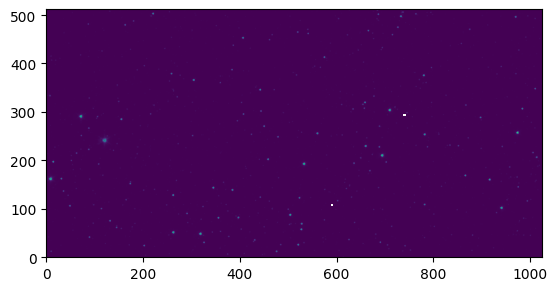

In [67]:
%matplotlib inline
# start by showing again the Spitzer image:

First find coordinates of 3 max pixels. Tip: use either np.argsort or np.argpartition.
Since there are NaN values, proceed carefully.

Define aperture radius, annulus inner and outer radii (possibly iterate depending on image you will plot in the next cell):

Finally plot your circles on the images:

### 2.3. Gradient estimate

More advanced tools to estimate 2D background images are also available in photutils. Most are based on a masking of the brightest sources (in a similar fashion as `sigma_clipped_stats`) followed by a smoothing (low-pass spatial filter) of the images.

**Example:** Let's make 100 Gaussian sources and add a smooth background gradient:

In [61]:
from photutils.datasets import make_100gaussians_image
data = make_100gaussians_image()

In [62]:
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize

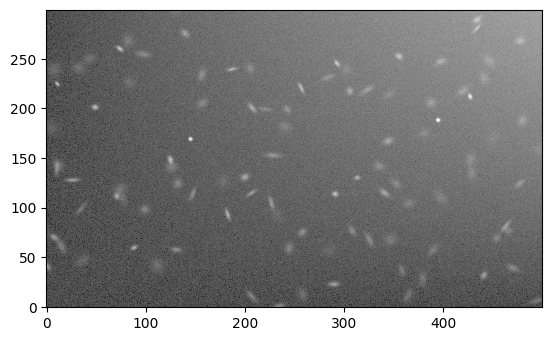

In [63]:
ny, nx = data.shape
y, x = np.mgrid[:ny, :nx]
gradient = x * y / 5000.0
data2 = data + gradient

norm = ImageNormalize(stretch=SqrtStretch())
plt.imshow(data2, norm=norm, origin='lower', cmap='Greys_r',
           interpolation='nearest')  

We start by creating a `Background2D` object using a box size of 50x50 and a 3x3 median filter. We will estimate the background level in each mesh as the sigma-clipped median using an instance of `MedianBackground`.

In [64]:
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground

sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()
bkg = Background2D(data2, (50, 50), filter_size=(3, 3),
                   sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)

Let’s plot the estimated background image:

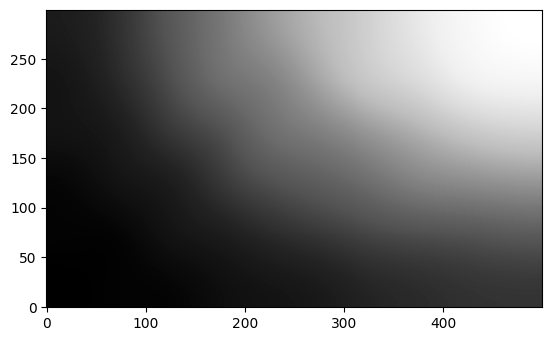

In [65]:
plt.imshow(bkg.background, origin='lower', cmap='Greys_r',
           interpolation='nearest')

And the background-subtracted image:

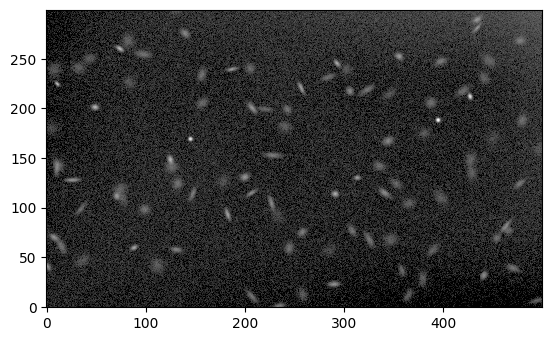

In [66]:
plt.imshow(data2 - bkg.background, norm=norm, origin='lower',
           cmap='Greys_r', interpolation='nearest')

Additional background estimation and subtraction methods available in `photutils` are described on [this page](https://photutils.readthedocs.io/en/stable/background.html).

<a class="anchor" id="det1"></a> <div class="alert alert-block alert-warning"> 
**Side note:** When dedicated background images are taken close in time from the science observation, these should be used to estimate and subtract the background. A straightforward approach is to subtract the median of the stack of background images. More advanced approaches rely on... PCA (cfr. Lecture 03)!
</div>

## 3. Source identification

### 3.1. Centroid measurement

`photutils.centroids` provides several functions to calculate the centroid of a single source:

- `centroid_com`: Calculates the object “center of mass” from 2D image moments.
- `centroid_quadratic`: Calculates the centroid by fitting a 2D quadratic polynomial to the data.
- `centroid_1dg`: Calculates the centroid by fitting 1D Gaussians to the marginal x and y distributions of the data.
- `centroid_2dg`: Calculates the centroid by fitting a 2D Gaussian to the 2D distribution of the data.

Masks can be input into each of these functions to mask bad pixels. Error arrays can be input into the two Gaussian fitting methods to weight the fits.

To calculate the centroids of many sources in an image, use the centroid_sources() function. This function can be used with any of the above centroiding functions or a custom user-defined centroiding function.

In [67]:
from photutils.datasets import make_4gaussians_image

data = make_4gaussians_image()[43:79, 76:104]

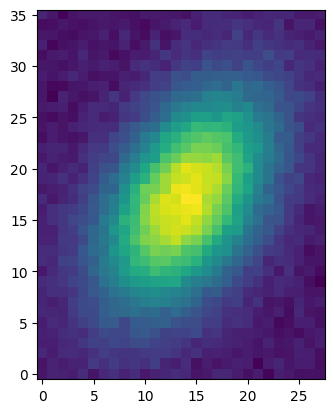

In [68]:
plt.imshow(data, origin='lower')

Let's compare the different methods:

In [69]:
from photutils.centroids import (centroid_1dg, centroid_2dg,
                                 centroid_com, centroid_quadratic)

Coordinates found corresponding to the center of mass (COM) of the image:

In [70]:
x1, y1 = centroid_com(data)
print((x1, y1))

(13.931579983412139, 17.051234441067088)


Coordinates found by fitting a 2D quadratic polynomial:

In [71]:
x2, y2 = centroid_quadratic(data)
print((x2, y2))  

(13.948284438186942, 16.987881994357604)


Coordinates found by fitting a 1D Gaussian:

In [72]:
x3, y3 = centroid_1dg(data)
print((x3, y3))

(14.040352707371394, 16.962306463644794)


Coordinates found by fitting a 2D Gaussian:

In [73]:
x4, y4 = centroid_2dg(data)
print((x4, y4))

(14.00221339471489, 16.99613641931417)


<a class="anchor" id="det1"></a> <div class="alert alert-block alert-warning"> 
**Side note:** An alternative for 2D model fitting, with a wider choice of models including also 2D Moffat or 2D Airy function, are the [2D model fitting utilities in Astropy](
https://docs.astropy.org/en/stable/modeling/fitting.html#simple-2-d-model-fitting).
</div>

Let's plot the results. Since they are all similar, let's include an inset:

(0.0, 35.0)

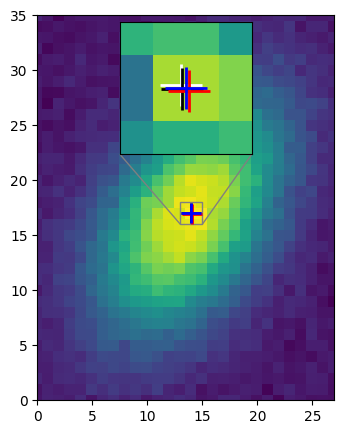

In [74]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import (mark_inset,
                                                   zoomed_inset_axes)
from photutils.centroids import (centroid_1dg, centroid_2dg,
                                 centroid_com, centroid_quadratic)
from photutils.datasets import make_4gaussians_image

data = make_4gaussians_image()[43:79, 76:104]  # extract single object
xycen1 = centroid_com(data)
xycen2 = centroid_quadratic(data)
xycen3 = centroid_1dg(data)
xycen4 = centroid_2dg(data)
xycens = [xycen1, xycen2, xycen3, xycen4]
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
ax.imshow(data, origin='lower', interpolation='nearest')
marker = '+'
ms, mew = 15, 2.0
colors = ('white', 'black', 'red', 'blue')
for xycen, color in zip(xycens, colors):
    plt.plot(*xycen, color=color, marker=marker, ms=ms, mew=mew)

ax2 = zoomed_inset_axes(ax, zoom=6, loc=9)
ax2.imshow(data, vmin=190, vmax=220, origin='lower',
           interpolation='nearest')
ms, mew = 30, 2.0
for xycen, color in zip(xycens, colors):
    ax2.plot(*xycen, color=color, marker=marker, ms=ms, mew=mew)
ax2.set_xlim(13, 15)
ax2.set_ylim(16, 18)
mark_inset(ax, ax2, loc1=3, loc2=4, fc='none', ec='0.5')
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)
ax.set_xlim(0, data.shape[1] - 1)
ax.set_ylim(0, data.shape[0] - 1)

<a class="anchor" id="det1"></a> <div class="alert alert-block alert-warning"> 
**Exercise 3.1:** Load all 5 images of M13 (`'M13_blue_000n.fits'`), then:

1. Estimate and subtract the background based on the method you deem the most fitting.
2. Align the images based on the location of their center of mass (align e.g. with respect to first one).
3. Stack them and write a new FITS file, including a modified header.

Tip: use the `shift` function from `scipy.ndimage` for subpixel shifts. Basic usage: `shifted_image = shift(image, (shift_y, shift_x))`. As usual more info in dosctrings.

</div>

### 3.2. Image alignment

A common task required before stacking astronomical images is to **align them** first. There is indeed always some jitter. An appropriate approach is to search for shifts that maximize the pair-wise cross-correlation between images of the stack.

`scikit-image` has a routine to do this, based on maximimizing cross-correlation in the Fourier plane: `phase_cross_correlation`.

**Example 1:** Pixel-precision alignment.

Known offset (y, x): (-22.4, 13.32)


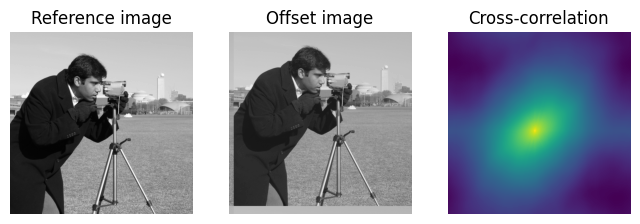

Detected pixel offset (y, x): [ 22. -13.]


In [75]:
from skimage import data
from skimage.registration import phase_cross_correlation
from skimage.registration._phase_cross_correlation import _upsampled_dft
from scipy.ndimage import fourier_shift

image = data.camera()
shift = (-22.4, 13.32)
# The shift corresponds to the pixel offset relative to the reference image
offset_image = fourier_shift(np.fft.fftn(image), shift)
offset_image = np.fft.ifftn(offset_image)
print(f'Known offset (y, x): {shift}')

# pixel precision first
shift, error, diffphase = phase_cross_correlation(image, offset_image) # with noisy images it is recommended to add: "normalization=None"

fig = plt.figure(figsize=(8, 3))
ax1 = plt.subplot(1, 3, 1)
ax2 = plt.subplot(1, 3, 2, sharex=ax1, sharey=ax1)
ax3 = plt.subplot(1, 3, 3)

ax1.imshow(image, cmap='gray')
ax1.set_axis_off()
ax1.set_title('Reference image')

ax2.imshow(offset_image.real, cmap='gray')
ax2.set_axis_off()
ax2.set_title('Offset image')

# Show the output of a cross-correlation to show what the algorithm is
# doing behind the scenes
image_product = np.fft.fft2(image) * np.fft.fft2(offset_image).conj()
cc_image = np.fft.fftshift(np.fft.ifft2(image_product))
ax3.imshow(cc_image.real)
ax3.set_axis_off()
ax3.set_title("Cross-correlation")

plt.show()

print(f'Detected pixel offset (y, x): {shift}')

For sub-pixel accuracy shifts, it is recommended to increase `upsample_factor` (e.g. `upsample_factor=100` means a requested precision of 1/100 pixel; increasing this parameter also makes it slower).

For noisy images, it is recommended to set `normalization=False`.

**Example 2:** Sub-pixel precision alignment.

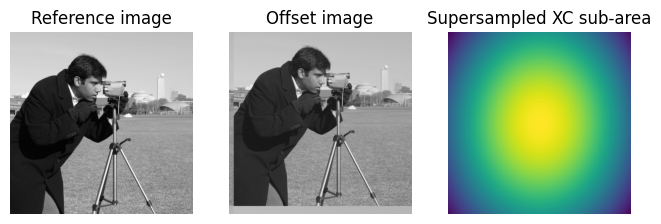

Detected subpixel offset (y, x): [ 22.4  -13.32]


In [76]:
# subpixel precision
shift, error, diffphase = phase_cross_correlation(image, offset_image,
                                                  upsample_factor=100) # with noisy images it is recommended to add: "normalization=None"

fig = plt.figure(figsize=(8, 3))
ax1 = plt.subplot(1, 3, 1)
ax2 = plt.subplot(1, 3, 2, sharex=ax1, sharey=ax1)
ax3 = plt.subplot(1, 3, 3)

ax1.imshow(image, cmap='gray')
ax1.set_axis_off()
ax1.set_title('Reference image')

ax2.imshow(offset_image.real, cmap='gray')
ax2.set_axis_off()
ax2.set_title('Offset image')

# Calculate the upsampled DFT, again to show what the algorithm is doing
# behind the scenes.  Constants correspond to calculated values in routine.
# See source code for details.
cc_image = _upsampled_dft(image_product, 150, 100, (shift * 100) + 75).conj()
ax3.imshow(cc_image.real)
ax3.set_axis_off()
ax3.set_title("Supersampled XC sub-area")


plt.show()

print(f'Detected subpixel offset (y, x): {shift}')

<a class="anchor" id="det1"></a> <div class="alert alert-block alert-warning"> 
**Exercise 3.2:** Same exercise as 3.1 but align the 5 images of M13 based on maximum cross-correlation, and with an upsample factor of 100:

1. Estimate and subtract the background based on the method you deem the most fitting.
2. Align the images with respect to the first one based on their pair-wise cross-correlation.
3. Stack them and write a new FITS file, including a modified header.

</div>

### 3.3. Automatic source finding

`Photutils` includes two widely-used tools that are used to detect stars in an image, DAOFIND and IRAF’s starfind, plus a third tool that allows input of a custom user-defined kernel. More details on them are available [here](https://photutils.readthedocs.io/en/stable/detection.html).

**Example:**

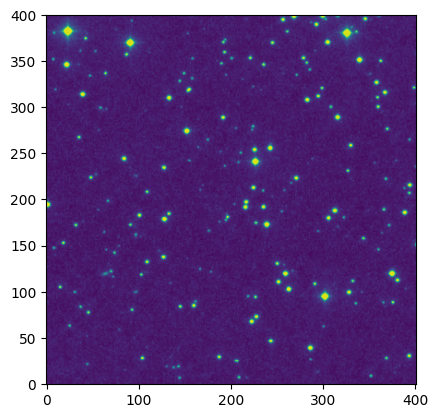

In [77]:
from astropy.stats import sigma_clipped_stats
from photutils.datasets import load_star_image
hdu = load_star_image()  
data = hdu.data[0:401, 0:401] 

plt.imshow(data, origin='lower')

In [78]:
mean, median, std = sigma_clipped_stats(data, sigma=3.0)  
print((mean, median, std))

(3668.09661145823, 3649.0, 204.41388592022315)


Now we will subtract the background and use an instance of DAOStarFinder to find the stars in the image that have FWHMs of around 3 pixels and have peaks approximately 5-sigma above the background. Running this class on the data yields an astropy Table containing the results of the star finder:

In [79]:
from photutils.detection import DAOStarFinder
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*std)  
sources = daofind(data - median)  
for col in sources.colnames:  
    if col not in ('id', 'npix'):
        sources[col].info.format = '%.2f'  # for consistent table output
sources.pprint(max_width=76)  

 id xcentroid ycentroid sharpness roundness1 ... sky    peak  flux  mag 
--- --------- --------- --------- ---------- ... ---- ------- ---- -----
  1    144.25      6.38      0.58       0.20 ... 0.00 6903.00 5.70 -1.89
  2    208.67      6.82      0.48      -0.13 ... 0.00 7896.00 6.72 -2.07
  3    216.93      6.58      0.69      -0.71 ... 0.00 2195.00 1.67 -0.55
  4    351.63      8.55      0.49      -0.34 ... 0.00 6977.00 5.90 -1.93
  5    377.52     12.07      0.52       0.37 ... 0.00 1260.00 1.12 -0.12
  6    294.27     12.74      0.68       0.11 ... 0.00 2059.00 1.48 -0.43
  7     85.22     14.71      0.62      -0.93 ... 0.00 1458.00 1.25 -0.24
  8    137.94     17.46      0.54       0.10 ... 0.00 5451.00 4.68 -1.68
  9    130.33     18.68      0.63       0.18 ... 0.00 3432.00 2.86 -1.14
 10    143.11     18.62      0.52       0.08 ... 0.00 6722.00 5.76 -1.90
 11    382.68     19.49      0.62      -0.31 ... 0.00 1350.00 1.34 -0.32
...       ...       ...       ...        ... ...  .

Let’s plot the image and mark the location of detected sources:

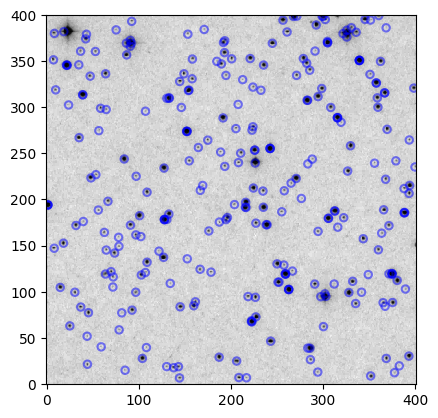

In [80]:
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from photutils.aperture import CircularAperture
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
apertures = CircularAperture(positions, r=4.0)
norm = ImageNormalize(stretch=SqrtStretch())
plt.imshow(data, cmap='Greys', origin='lower', norm=norm,
           interpolation='nearest')
apertures.plot(color='blue', lw=1.5, alpha=0.5)

<a class="anchor" id="det1"></a> <div class="alert alert-block alert-warning"> 
**Exercise 3.3:** Take the image of the Horsehead nebula (`'data/HorseHead.fits'`):

1. Automatically find stars in the HorseHead nebula image,
2. Overplot circles at their location,
3. Estimate the Poisson noise,
4. Measure the aperture photometry of the stars including uncertainties, and after subtracting annular estimates of the background.

</div>

<a class="anchor" id="det1"></a> <div class="alert alert-block alert-warning"> 
**Side note:** In this lecture, we only considered the case of measuring the photometry of unresolved point sources. For **extended elliptical sources** (e.g. galaxies) it is common to use **isophotes** instead. The interested reader can refer to the [following instructions](https://photutils.readthedocs.io/en/stable/isophote.html) explaining how to use the tools available in `photutils` in such case. A more general, yet very convenient, `photutils` tool can also provide the [morphological properties](https://photutils.readthedocs.io/en/stable/morphology.html) of the intensity distribution.
</div>

[Go back to top](#Table-of-contents)

## References

- This notebook is mostly based on the astropy tutorials available [here](https://learn.astropy.org/).
- Your reference for using `astropy` should be the [online documentation](http://docs.astropy.org/en/latest). Here are links to specific documentation on [quantities](https://docs.astropy.org/en/stable/units/index.html), [constants](https://docs.astropy.org/en/stable/constants/index.html), the [`wcs` module](http://docs.astropy.org/en/stable/visualization/wcsaxes/), [FITS handling](https://docs.astropy.org/en/stable/io/fits/index.html), [`coordinates`](http://docs.astropy.org/en/stable/coordinates/index.html), [`Table` objects](http://docs.astropy.org/en/stable/table/io.html), and [modeling](https://docs.astropy.org/en/stable/modeling/index.html).
- Photutils documentation on [aperture photometry](https://photutils.readthedocs.io/en/stable/aperture.html) and [isophotes](https://photutils.readthedocs.io/en/stable/isophote.html).
- Scikit-image documentation on [phase cross-correlation](https://scikit-image.org/docs/stable/auto_examples/registration/plot_register_translation.html). 

## Credits:

If you use Astropy directly—or as a dependency to another package—for your work, please remember to include the following acknowledgment at the end of papers:

*This research made use of Astropy, a community-developed core Python package for Astronomy (Astropy Collaboration, 2013).*

Where the astropy paper is 2013, A&A, 558, 33 http://adsabs.harvard.edu//abs/2013A%26A...558A..33A

[Go back to top](#Table-of-contents)